# Часть 3
Объясняем продюсеру Рост ARPDAU при падающем D1 

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(7)
pd.set_option('display.float_format', '{:.4f}'.format)

## Эффект селекции: ARPDAU растёт при падающем D1

In [9]:
DAYS = 30
N_INSTALLS_PER_DAY = 5000

PAYER_BASE_SHARE = 0.05
PAYER_D1_RETENTION = 0.62
PAY_PROB_PER_DAY = 0.40
GAMMA_SHAPE, GAMMA_SCALE = 2.0, 3.0

def simulate_day(day, regression_started=10, regression_d1_drop=0.07):
    base_d1 = 0.34
    target_d1 = base_d1 - regression_d1_drop * max(0, day - regression_started) / 10
    target_d1 = max(target_d1, 0.18)

    n = N_INSTALLS_PER_DAY
    is_payer = np.random.binomial(1, PAYER_BASE_SHARE, n)

    free_d1 = (target_d1 - PAYER_BASE_SHARE * PAYER_D1_RETENTION) / (1 - PAYER_BASE_SHARE)
    free_d1 = max(free_d1, 0.05)
    retained = np.where(
        is_payer == 1,
        np.random.binomial(1, PAYER_D1_RETENTION, n),
        np.random.binomial(1, free_d1, n),
    )

    paid_today = (is_payer == 1) & (retained == 1) & (np.random.binomial(1, PAY_PROB_PER_DAY, n) == 1)
    revenue = np.where(paid_today, np.random.gamma(GAMMA_SHAPE, GAMMA_SCALE, n), 0.0)

    return pd.DataFrame({
        'day': day,
        'retained': retained,
        'is_payer': is_payer,
        'revenue': revenue,
    })

frames = [simulate_day(d) for d in range(DAYS)]
sim = pd.concat(frames, ignore_index=True)

retained_sim = sim[sim.retained == 1]
daily = retained_sim.groupby('day').agg(
    dau=('retained', 'sum'),
    revenue=('revenue', 'sum'),
    payers=('is_payer', 'sum'),
).reset_index()
daily['arpdau'] = daily['revenue'] / daily['dau']
daily['arppu'] = daily['revenue'] / daily['payers']
daily['payer_share'] = daily['payers'] / daily['dau']
daily['d1_proxy'] = daily['dau'] / N_INSTALLS_PER_DAY

daily.head(15)

,day,dau,revenue,payers,arpdau,arppu,payer_share,d1_proxy
0,0,1704,331.4565,153,0.1945,2.1664,0.0898,0.3408
1,1,1688,296.2004,153,0.1755,1.9360,0.0906,0.3376
2,2,1688,340.5941,157,0.2018,2.1694,0.0930,0.3376
3,3,1720,413.9616,177,0.2407,2.3388,0.1029,0.3440
4,4,1700,281.1494,142,0.1654,1.9799,0.0835,0.3400
5,5,1708,317.1332,156,0.1857,2.0329,0.0913,0.3416
6,6,1651,348.2991,144,0.2110,2.4187,0.0872,0.3302
7,7,1688,337.3222,140,0.1998,2.4094,0.0829,0.3376
8,8,1664,334.5511,144,0.2011,2.3233,0.0865,0.3328
9,9,1669,474.2879,163,0.2842,2.9097,0.0977,0.3338


In [10]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['D1 retention', 'ARPDAU', 'ARPPU (стабилен -> селекция)', 'Доля платящих в DAU'],
)

fig.add_trace(go.Scatter(x=daily.day, y=daily.d1_proxy, line={'color': '#c0392b'}, name='D1'), row=1, col=1)
fig.add_trace(go.Scatter(x=daily.day, y=daily.arpdau, line={'color': '#27ae60'}, name='ARPDAU'), row=1, col=2)
fig.add_trace(go.Scatter(x=daily.day, y=daily.arppu, line={'color': '#7f8fa6'}, name='ARPPU'), row=2, col=1)
fig.add_trace(go.Scatter(x=daily.day, y=daily.payer_share, line={'color': '#8e44ad'}, name='payer share'), row=2, col=2)

fig.add_vline(x=10, line_dash='dash', line_color='gray', row=1, col=1)
fig.add_vline(x=10, line_dash='dash', line_color='gray', row=1, col=2)
fig.add_vline(x=10, line_dash='dash', line_color='gray', row=2, col=1)
fig.add_vline(x=10, line_dash='dash', line_color='gray', row=2, col=2)

fig.update_layout(template='plotly_white', height=620, showlegend=False, title='Симуляция: D1 падает -> ARPDAU растёт, но ARPPU стоит на месте')
fig.show()

In [11]:
before = daily[daily.day < 10].mean(numeric_only=True)
after = daily[daily.day >= 20].mean(numeric_only=True)
delta = pd.DataFrame({'before': before, 'after': after, 'delta_pct': (after - before) / before * 100})
delta.loc[['d1_proxy', 'arpdau', 'arppu', 'payer_share']].round(4)

,before,after,delta_pct
d1_proxy,0.3376,0.2406,-28.7263
arpdau,0.2060,0.3333,61.8258
arppu,2.2685,2.4663,8.7209
payer_share,0.0906,0.1337,47.6915


Ровно то, что написано в Части 3: ARPDAU вырос, ARPPU не двинулся, доля платящих в DAU выросла. Это не рост платежей — это смещение выборки.

## Когортный разрез D1 для диагностики

In [12]:
def cohort_d1(channel, platform, regression_day, base_d1=0.34, drop=0.0):
    days = np.arange(DAYS)
    d1 = np.where(days < regression_day, base_d1, base_d1 - drop)
    return pd.DataFrame({'day': days, 'channel': channel, 'platform': platform, 'd1': d1})

cohorts = pd.concat([
    cohort_d1('organic', 'ios', 30, 0.36, 0.00),
    cohort_d1('organic', 'android', 30, 0.32, 0.00),
    cohort_d1('paid_ua_a', 'ios', 10, 0.35, 0.10),
    cohort_d1('paid_ua_a', 'android', 10, 0.30, 0.09),
    cohort_d1('paid_ua_b', 'ios', 30, 0.34, 0.00),
    cohort_d1('paid_ua_b', 'android', 30, 0.28, 0.00),
], ignore_index=True)

cohorts['noise'] = np.random.normal(0, 0.012, len(cohorts))
cohorts['d1_obs'] = (cohorts['d1'] + cohorts['noise']).clip(0, 1)

fig = go.Figure()
for (ch, pl), grp in cohorts.groupby(['channel', 'platform']):
    fig.add_trace(go.Scatter(
        x=grp['day'], y=grp['d1_obs'],
        mode='lines',
        name=f'{ch} / {pl}',
    ))
fig.add_vline(x=10, line_dash='dash', line_color='gray', annotation_text='релиз / момент падения D1')
fig.update_layout(
    title='D1 по когортам: проседание сидит в одном UA-канале',
    xaxis_title='день',
    yaxis_title='D1',
    template='plotly_white',
    height=460,
)
fig.show()

Картинка отвечает на вопрос «продуктовый регресс или сменился микс трафика»: проседание локализовано в `paid_ua_a`, остальные когорты не двигаются.

## LTV-проекция: что будет с накопительной выручкой

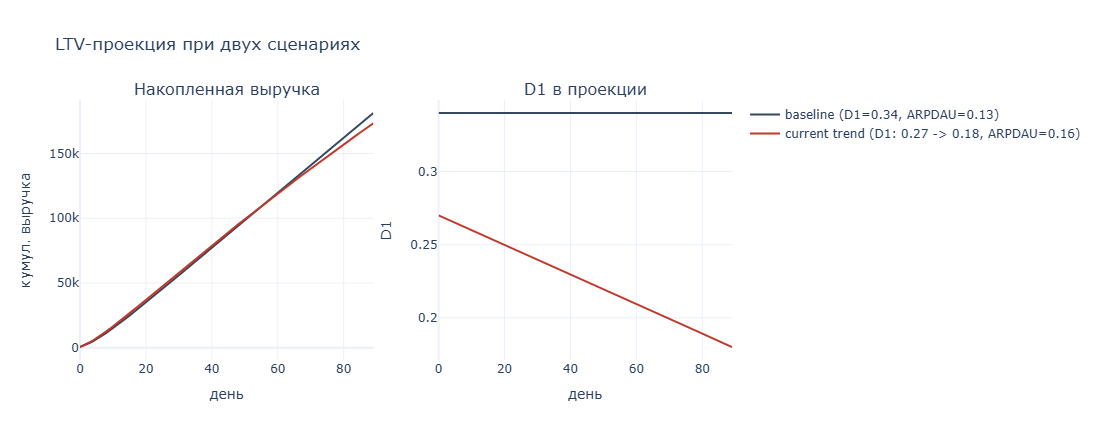

Накопленная выручка к D90:
  baseline:             181,278
  current trend:        173,396
  delta:           -4.3%

Точка пересечения (день, когда current отстал от baseline):
  day 57: baseline=113,332, current=113,251


In [13]:
def project_revenue(d1_curve, arpdau_curve, n_install_per_day=5000, retention_decay=0.85):
    days = len(d1_curve)
    revenue = np.zeros(days)
    for t in range(days):
        active = 0
        for cohort_day in range(t + 1):
            age = t - cohort_day
            ret = d1_curve[cohort_day] * (retention_decay ** (age - 1)) if age >= 1 else 1.0
            active += n_install_per_day * ret
        revenue[t] = active * arpdau_curve[t]
    return np.cumsum(revenue)

DAYS_PROJ = 90

d1_baseline = np.full(DAYS_PROJ, 0.34)
arpdau_baseline = np.full(DAYS_PROJ, 0.13)

d1_current = np.linspace(0.27, 0.18, DAYS_PROJ)
arpdau_current = np.full(DAYS_PROJ, 0.16)

baseline = project_revenue(d1_baseline, arpdau_baseline)
current = project_revenue(d1_current, arpdau_current)

x = np.arange(DAYS_PROJ)
fig = make_subplots(rows=1, cols=2, subplot_titles=['Накопленная выручка', 'D1 в проекции'])

fig.add_trace(go.Scatter(x=x, y=baseline, name='baseline (D1=0.34, ARPDAU=0.13)', line={'color': '#34495e'}), row=1, col=1)
fig.add_trace(go.Scatter(x=x, y=current, name='current trend (D1: 0.27 -> 0.18, ARPDAU=0.16)', line={'color': '#c0392b'}), row=1, col=1)

fig.add_trace(go.Scatter(x=x, y=d1_baseline, line={'color': '#34495e'}, showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=x, y=d1_current, line={'color': '#c0392b'}, showlegend=False), row=1, col=2)

fig.update_layout(template='plotly_white', height=440, title='LTV-проекция при двух сценариях')
fig.update_yaxes(title_text='кумул. выручка', row=1, col=1)
fig.update_yaxes(title_text='D1', row=1, col=2)
fig.update_xaxes(title_text='день')
fig.show()

print(f"Накопленная выручка к D90:")
print(f"  baseline:        {baseline[-1]:>12,.0f}")
print(f"  current trend:   {current[-1]:>12,.0f}")
print(f"  delta:           {(current[-1] - baseline[-1]) / baseline[-1] * 100:+.1f}%")
print()
print(f"Точка пересечения (день, когда current отстал от baseline):")
crossover = np.argmax(current < baseline)
print(f"  day {crossover}: baseline={baseline[crossover]:,.0f}, current={current[crossover]:,.0f}")

На этом сценарии накопительная выручка отстаёт от baseline, несмотря на то, что ARPDAU выше. Ключ — D1 продолжает падать. Если D1 стабилизируется на 0.27, сценарий получается даже выгоднее baseline (на текущем ARPDAU). Поэтому правильный ответ продюсеру — «надо проверять» (а не «всё плохо» или «всё ок»): итог зависит от того, продолжится ли тренд.